# Unified Engineering 16.002
## ODE Primer (Modular Script Version)
Each major section is stored as a standalone Python script. In each section below, the script is displayed first and then executed.

In [3]:
from pathlib import Path
import runpy
import sys
from IPython.display import Code, display

SCRIPT_DIR = Path.home() / "MIT Dropbox" / "Jonathan How" / "Classes" / "16.002" / "Fall2026" / "ODEPrimer" / "scripts"
FIG_DIR = SCRIPT_DIR.parent / "figs"

if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

def show_script(name):
    path = SCRIPT_DIR / name
    print(f"Showing: {path}")
    display(Code(filename=str(path), language="python"))

def run_script(name):
    path = SCRIPT_DIR / name
    print(f"Running: {path}")
    runpy.run_path(str(path), run_name="__main__")

print(f"Scripts: {SCRIPT_DIR}")
print(f"Figures: {FIG_DIR}")

Scripts: /Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.002/Fall2026/ODEPrimer/scripts
Figures: /Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.002/Fall2026/ODEPrimer/figs


## First Order Example

In [4]:
show_script("01_first_order.py")

Showing: /Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.002/Fall2026/ODEPrimer/scripts/01_first_order.py


import numpy as np
import matplotlib.pyplot as plt

from ode_common import default_inputs, output_dir, solve_ode


def main():
    phi = 0.0
    we, wc = default_inputs(phi)
    Y0 = [4]
    A = [1, 3]

    fun_0 = solve_ode(A=A, w=0, Y0=Y0)
    fun_1 = solve_ode(A=A, w=9, Y0=Y0)
    fun_2 = solve_ode(A=A, w=we, Y0=Y0)
    fun_3 = solve_ode(A=A, w=wc, Y0=Y0)

    tt = np.arange(0, 6, 0.01)
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot()
    ax.plot(tt, fun_0(tt), "b-", label="homogeneous", lw=3)
    ax.plot(tt, fun_1(tt), "r-", label="w(t)=9")
    ax.plot(tt, fun_2(tt), "g--", label="3exp(-3t)", lw=3)
    ax.plot(tt, fun_3(tt), "m", label=f"3cos(3t + {phi:3.2})")
    ax.set_xlabel("Time")
    ax.text(4, 0.75, "y(0) = " + str(Y0))
    ax.legend()
    ax.set_title("First Order $\\dot y(t) + 3y(t) = w(t)$")

    out = output_dir()
    fig.savefig(out / "first_order.png", dpi=300)
    fig.savefig(out / "first_order.pdf")
    plt.show()


if __name__ == "__main__":
    main()

Running: /Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.002/Fall2026/ODEPrimer/scripts/01_first_order.py


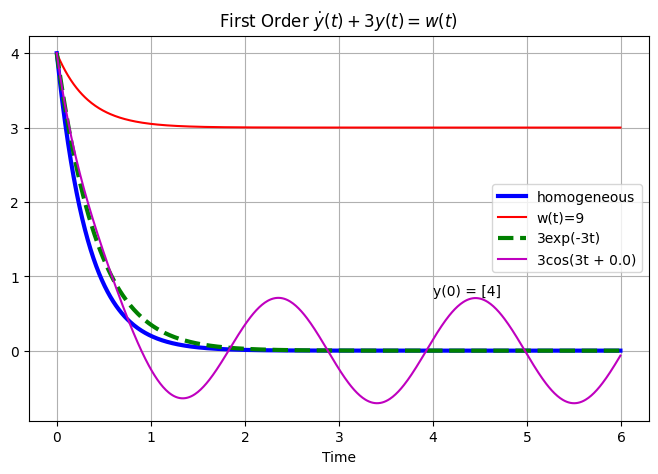

In [5]:
run_script("01_first_order.py")

## Second Order (Real Poles)

In [6]:
show_script("02_second_order_real.py")

Showing: /Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.002/Fall2026/ODEPrimer/scripts/02_second_order_real.py


import numpy as np
import matplotlib.pyplot as plt

from ode_common import default_inputs, output_dir, solve_ode


def main():
    phi = 0.0
    we, wc = default_inputs(phi)
    Y0 = [1, 0]
    A = [1, 3, 2]

    fun_0 = solve_ode(A=A, w=0, Y0=Y0)
    fun_1 = solve_ode(A=A, w=1, Y0=Y0)
    fun_2 = solve_ode(A=A, w=we, Y0=Y0)
    fun_3 = solve_ode(A=A, w=wc, Y0=Y0)

    tt = np.arange(0, 10, 0.01)
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot()
    ax.plot(tt, fun_0(tt), "b-", label="homogeneous", lw=3)
    ax.plot(tt, fun_1(tt), "r-", label="w(t)=1")
    ax.plot(tt, fun_2(tt), "g--", label="3exp(-3t)", lw=3)
    ax.plot(tt, fun_3(tt), "m", label=f"3cos(3t + {phi:3.2})")
    ax.text(4, 0.75, "y(0) = " + str(Y0[0]) + ", dy(0)/dt = " + str(Y0[1]))
    ax.set_xlabel("Time")
    ax.legend()
    ax.set_title("Second Order: $\\ddot y(t) + 3\\dot y(t) + 2y(t) = w(t)$")

    out = output_dir()
    fig.savefig(out / "second_order.png", dpi=300)
    fig.savefig(out / "second_order.pdf")
    plt.show()


if __name__ == "__main__":
    main()

Running: /Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.002/Fall2026/ODEPrimer/scripts/02_second_order_real.py


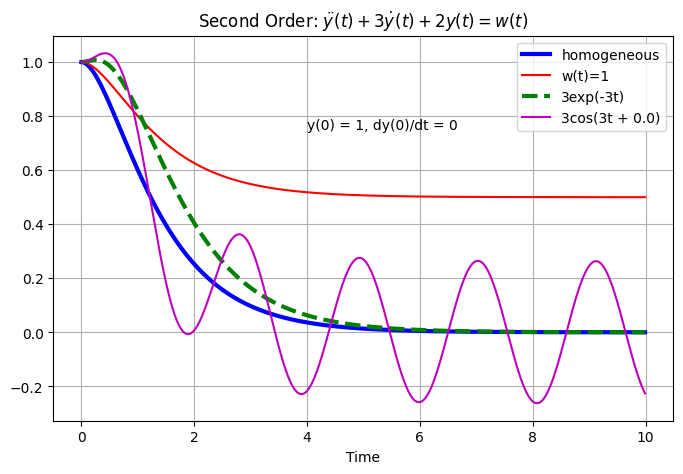

In [7]:
run_script("02_second_order_real.py")

## Second Order (Complex Poles)

In [8]:
show_script("03_second_order_complex.py")

Showing: /Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.002/Fall2026/ODEPrimer/scripts/03_second_order_complex.py


import numpy as np
import matplotlib.pyplot as plt

from ode_common import default_inputs, output_dir, solve_ode


def main():
    phi = 0.0
    we, wc = default_inputs(phi)
    Y0 = [1, 0]
    A = [1, 2, 10]

    fun_0 = solve_ode(A=A, w=0, Y0=Y0)
    fun_1 = solve_ode(A=A, w=1, Y0=Y0)
    fun_2 = solve_ode(A=A, w=we, Y0=Y0)
    fun_3 = solve_ode(A=A, w=wc, Y0=Y0)

    tt = np.arange(0, 10, 0.01)
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot()
    ax.plot(tt, fun_0(tt), "b-", label="homogeneous", lw=3)
    ax.plot(tt, fun_1(tt), "r-", label=r"$w(t)=1$")
    ax.plot(tt, fun_2(tt), "g--", label=r"$3exp^{-3t}$", lw=3)
    ax.plot(tt, fun_3(tt), "m", label=r"$3cos(3t + " + str(phi) + r")$")
    ax.text(4, 0.75, "y(0) = " + str(Y0[0]) + r", $\dot y(0) =$ " + str(Y0[1]))
    ax.set_xlabel("Time")
    ax.legend()
    a2_str = f"{A[0]:.0f}" if A[0] != 1 else ""
    ax.set_title(
        rf"Second Order/Complex: ${a2_str}\ddot y(t) + {A[1]:.0f}\dot y(t) + {A[2]:.0f}y(t) = w(t)$"
    )

    out = output_dir()
    fig.savefig(out / "second_order_complex.png", dpi=300)
    fig.savefig(out / "second_order_complex.pdf")
    plt.show()


if __name__ == "__main__":
    main()

Running: /Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.002/Fall2026/ODEPrimer/scripts/03_second_order_complex.py


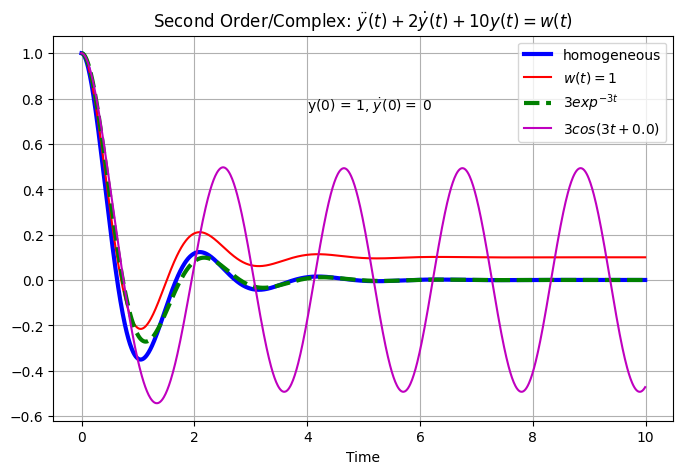

In [9]:
run_script("03_second_order_complex.py")

## Second Order (Repeated Pole)

In [10]:
show_script("04_second_order_repeated.py")

Showing: /Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.002/Fall2026/ODEPrimer/scripts/04_second_order_repeated.py


import numpy as np
import matplotlib.pyplot as plt

from ode_common import default_inputs, output_dir, solve_ode


def main():
    phi = 0.0
    we, wc = default_inputs(phi)
    Y0 = [1, 1]
    A = [1, 2, 1]

    fun_0 = solve_ode(A=A, w=0, Y0=Y0)
    fun_1 = solve_ode(A=A, w=1, Y0=Y0)
    fun_2 = solve_ode(A=A, w=we, Y0=Y0)
    fun_3 = solve_ode(A=A, w=wc, Y0=Y0)

    tt = np.arange(0, 10, 0.01)
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot()
    ax.plot(tt, fun_0(tt), "b-", label="homogeneous", lw=3)
    ax.plot(tt, fun_1(tt), "r-", label=r"$w(t)=1$")
    ax.plot(tt, fun_2(tt), "g--", label=r"$3exp^{-3t}$", lw=3)
    ax.plot(tt, fun_3(tt), "m", label=r"$3cos(3t)$")
    ax.text(4, 0.75, "y(0) = " + str(Y0[0]) + r", $\dot y(0) =$ " + str(Y0[1]))
    ax.set_xlabel("Time")
    ax.legend()
    ax.set_title("Second Order/Repeated: $\\ddot y(t) + 2\\dot y(t) + y(t) = w(t)$")

    out = output_dir()
    fig.savefig(out / "second_order_repeated.png", dpi=300)
    fig.savefig(out / "second_order_repeated.pdf")
    plt.show()


if __name__ == "__main__":
    main()

Running: /Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.002/Fall2026/ODEPrimer/scripts/04_second_order_repeated.py


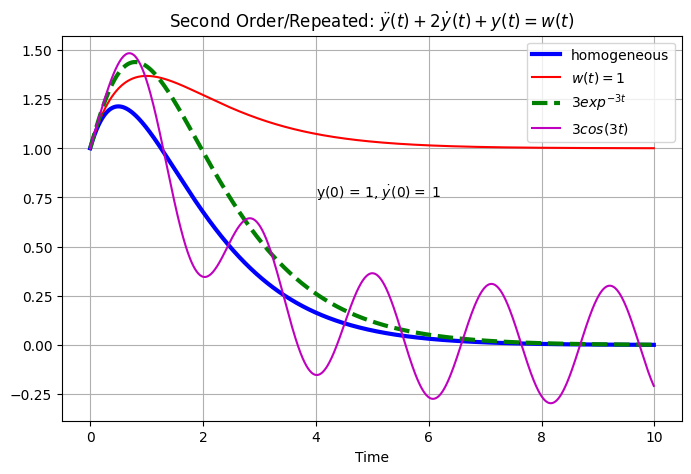

In [11]:
run_script("04_second_order_repeated.py")

## Advanced Symbolic Inputs

In [12]:
show_script("05_advanced_symbolic_inputs.py")

Showing: /Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.002/Fall2026/ODEPrimer/scripts/05_advanced_symbolic_inputs.py


import sympy as sym

from ode_common import t, y


def main():
    A = [1, 3, 2]

    g0 = A[0] * y.diff(t, t) + A[1] * y.diff(t) + A[2] * y - sym.DiracDelta(t)
    impulse = sym.dsolve(g0, ics={y.subs(t, 0): 0, sym.diff(y, t).subs(t, 0): 0})

    g1 = A[0] * y.diff(t, t) + A[1] * y.diff(t) + A[2] * y - sym.Heaviside(t)
    step = sym.dsolve(g1, ics={y.subs(t, 0): 0, sym.diff(y, t).subs(t, 0): 0})

    print("Impulse response solution:")
    sym.pprint(impulse)
    print("\nStep response solution:")
    sym.pprint(step)


if __name__ == "__main__":
    main()

In [13]:
run_script("05_advanced_symbolic_inputs.py")

Running: /Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.002/Fall2026/ODEPrimer/scripts/05_advanced_symbolic_inputs.py
Impulse response solution:
       ⎛              -t          1⎞  -t
y(t) = ⎜(1/2 - θ(t))⋅ℯ   + θ(t) - ─⎟⋅ℯ  
       ⎝                          2⎠    

Step response solution:
                          -2⋅t     
       θ(t)    -t        ℯ    ⋅θ(t)
y(t) = ──── - ℯ  ⋅θ(t) + ──────────
        2                    2     


## Numerical vs Analytical Comparison

In [14]:
show_script("06_numerical_vs_analytical.py")

Showing: /Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.002/Fall2026/ODEPrimer/scripts/06_numerical_vs_analytical.py


import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from ode_common import default_inputs, output_dir, solve_ode


def main():
    phi = 0.0
    we, wc = default_inputs(phi)

    Y0 = [1, 0]
    A = [1, 3, 2]

    W0 = lambda t: 0.0
    W1 = lambda t: 1.0
    We = lambda t: 3.0 * np.exp(-3.0 * t)
    Wc = lambda t: 3.0 * np.cos(3.0 * t)

    def odes(t, Y, W):
        y, v = Y
        dvdt = W(t) - A[1] / A[0] * v - A[2] / A[0] * y
        return [v, dvdt]

    t_span = [0, 10]
    t_eval = np.linspace(t_span[0], t_span[1], 100)

    solution_0 = solve_ivp(odes, t_span, Y0, t_eval=t_eval, args=(W0,))
    solution_1 = solve_ivp(odes, t_span, Y0, t_eval=t_eval, args=(W1,))
    solution_e = solve_ivp(odes, t_span, Y0, t_eval=t_eval, args=(We,))
    solution_c = solve_ivp(odes, t_span, Y0, t_eval=t_eval, args=(Wc,))

    fun_0 = solve_ode(A=A, w=0, Y0=Y0)
    fun_1 = solve_ode(A=A, w=1, Y0=Y0)
    fun_2 = solve_ode(A=A, w=we, Y0=Y0)
    fun_3 = solve_ode(A=A, w=wc, Y0=Y0)

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot()
    ax.plot(solution_0.t, solution_0.y[0], "bs", label="Numerical homogeneous", ms=4, markevery=4)
    ax.plot(solution_1.t, solution_1.y[0], "rs", label="Numerical w(t)=1", ms=4, markevery=4)
    ax.plot(solution_e.t, solution_e.y[0], "gs", label="Numerical 3exp(-3t)", ms=4, markevery=4)
    ax.plot(solution_c.t, solution_c.y[0], "ms", label="Numerical 3cos(3t)", ms=4, markevery=4)

    ax.plot(t_eval, fun_0(t_eval), "b-", label="Analytical homogeneous", lw=3)
    ax.plot(t_eval, fun_1(t_eval), "r-", label=r"Analytical $w(t)=1$")
    ax.plot(t_eval, fun_2(t_eval), "g--", label=r"Analytical $3exp^{-3t}$", lw=3)
    ax.plot(t_eval, fun_3(t_eval), "m", label=r"Analytical $3cos(3t)$")

    ax.text(4, 0.75, "y(0) = " + str(Y0[0]) + r", $\dot y(0) =$ " + str(Y0[1]))
    ax.set_xlabel("Time t")
    ax.set_ylabel("Solution")
    ax.set_title("Second Order: $\\ddot y(t) + 3\\dot y(t) + 2y(t) = w(t)$")
    ax.grid(True)
    ax.legend()

    out = output_dir()
    fig.savefig(out / "second_order_numerical_compare.png", dpi=300)
    fig.savefig(out / "second_order_numerical_compare.pdf")
    plt.show()


if __name__ == "__main__":
    main()

Running: /Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.002/Fall2026/ODEPrimer/scripts/06_numerical_vs_analytical.py


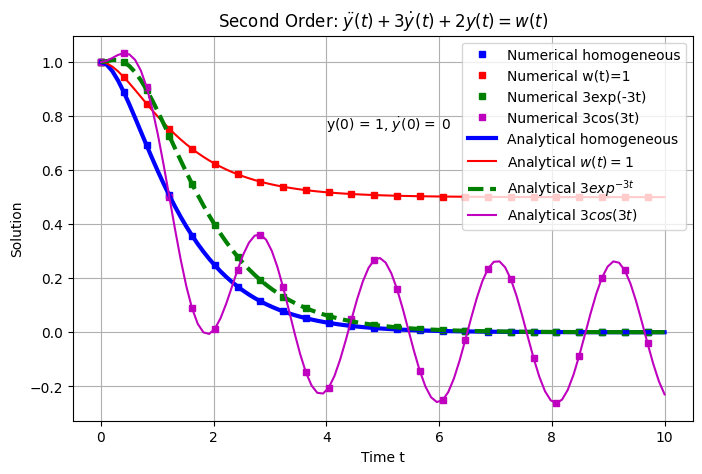

In [15]:
run_script("06_numerical_vs_analytical.py")